In [232]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [233]:
ticker_symbol = "SPY"
ticker = yf.Ticker(ticker_symbol)


In [234]:
history = ticker.history(period="5d")

spot_price = history["Close"].iloc[-1]

print("Current SPY price:", spot_price)
print(pd.DataFrame(history))

Current SPY price: 750.4849853515625
                                 Open        High         Low       Close  \
Date                                                                        
2026-06-11 00:00:00-04:00  728.760010  740.000000  724.409973  737.760010   
2026-06-12 00:00:00-04:00  740.710022  744.440002  735.030029  741.750000   
2026-06-15 00:00:00-04:00  751.849976  756.679993  751.760010  754.830017   
2026-06-16 00:00:00-04:00  754.549988  755.440002  749.880005  750.330017   
2026-06-17 00:00:00-04:00  751.289978  752.150024  747.849976  750.484985   

                             Volume  Dividends  Stock Splits  Capital Gains  
Date                                                                         
2026-06-11 00:00:00-04:00  86330500        0.0           0.0            0.0  
2026-06-12 00:00:00-04:00  57079500        0.0           0.0            0.0  
2026-06-15 00:00:00-04:00  60176400        0.0           0.0            0.0  
2026-06-16 00:00:00-04:00  670132

In [235]:
expirations = ticker.options

print(expirations)

('2026-06-17', '2026-06-18', '2026-06-22', '2026-06-23', '2026-06-24', '2026-06-25', '2026-06-26', '2026-06-29', '2026-06-30', '2026-07-02', '2026-07-10', '2026-07-17', '2026-07-24', '2026-07-31', '2026-08-21', '2026-08-31', '2026-09-18', '2026-09-30', '2026-10-16', '2026-10-30', '2026-11-20', '2026-11-30', '2026-12-18', '2026-12-31', '2027-01-15', '2027-03-19', '2027-03-31', '2027-06-17', '2027-09-17', '2027-12-17', '2028-01-21', '2028-06-16', '2028-12-15')


In [236]:
expiration = expirations[12]

print("Selected expiration:", expiration)

Selected expiration: 2026-07-24


In [237]:
option_chain = ticker.option_chain(expiration)

calls = option_chain.calls

puts = option_chain.puts

calls.head()

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,SPY260724C00500000,2026-06-16 15:28:06+00:00,500.0,253.44,248.46,251.83,0.0,0.0,2.0,1,0.654422,True,REGULAR,USD
1,SPY260724C00540000,2026-06-12 13:40:46+00:00,540.0,198.27,208.78,212.07,0.0,0.0,NaN,3,0.561894,True,REGULAR,USD
2,SPY260724C00550000,2026-06-05 13:30:02+00:00,550.0,203.71,198.86,202.20,0.0,0.0,2.0,2,0.542973,True,REGULAR,USD
3,SPY260724C00560000,2026-06-05 19:17:21+00:00,560.0,178.71,188.94,192.29,0.0,0.0,11.0,11,0.521245,True,REGULAR,USD
4,SPY260724C00570000,2026-06-09 16:38:21+00:00,570.0,156.99,179.03,182.32,0.0,0.0,NaN,1,0.496343,True,REGULAR,USD


In [238]:
calls = calls[
   [
       "strike",
        "bid",
        "ask",
        "lastPrice",
        "volume",
        "openInterest",
        "impliedVolatility"
    ]

].copy()

calls.head()

,strike,bid,ask,lastPrice,volume,openInterest,impliedVolatility
0,500.0,248.46,251.83,253.44,2.0,1,0.654422
1,540.0,208.78,212.07,198.27,NaN,3,0.561894
2,550.0,198.86,202.20,203.71,2.0,2,0.542973
3,560.0,188.94,192.29,178.71,11.0,11,0.521245
4,570.0,179.03,182.32,156.99,NaN,1,0.496343


In [239]:
calls["mid_price"] = (calls["bid"] + calls["ask"]) / 2
calls[["strike", "bid", "ask", "mid_price"]].head(10)

,strike,bid,ask,mid_price
0,500.0,248.46,251.83,250.145
1,540.0,208.78,212.07,210.425
2,550.0,198.86,202.20,200.530
3,560.0,188.94,192.29,190.615
4,570.0,179.03,182.32,180.675
5,595.0,154.27,157.63,155.950
6,600.0,149.32,152.68,151.000
7,605.0,144.39,147.74,146.065
8,615.0,134.61,137.86,136.235
9,620.0,129.64,132.93,131.285


In [240]:
calls = calls[ (calls["bid"] > 0) & (calls["ask"] > calls["bid"])].copy()

calls["relative_spread"] = (calls["ask"] - calls["bid"]) / calls["mid_price"]

calls = calls[calls["relative_spread"] < 0.30].copy()

calls = calls[calls["openInterest"] > 0].copy()

calls.head()

,strike,bid,ask,lastPrice,volume,openInterest,impliedVolatility,mid_price,relative_spread
0,500.0,248.46,251.83,253.44,2.0,1,0.654422,250.145,0.013472
1,540.0,208.78,212.07,198.27,NaN,3,0.561894,210.425,0.015635
2,550.0,198.86,202.20,203.71,2.0,2,0.542973,200.530,0.016656
3,560.0,188.94,192.29,178.71,11.0,11,0.521245,190.615,0.017575
4,570.0,179.03,182.32,156.99,NaN,1,0.496343,180.675,0.018209


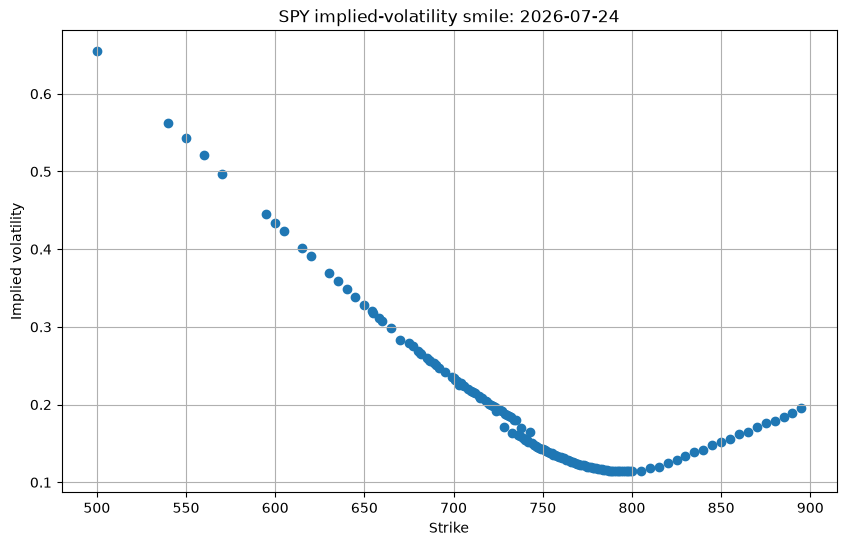

In [241]:
plt.figure(figsize=(10, 6))

plt.scatter(
    calls["strike"],
    calls["impliedVolatility"]
)

plt.xlabel("Strike")
plt.ylabel("Implied volatility")
plt.title(f"SPY implied-volatility smile: {expiration}")
plt.grid()

plt.show()

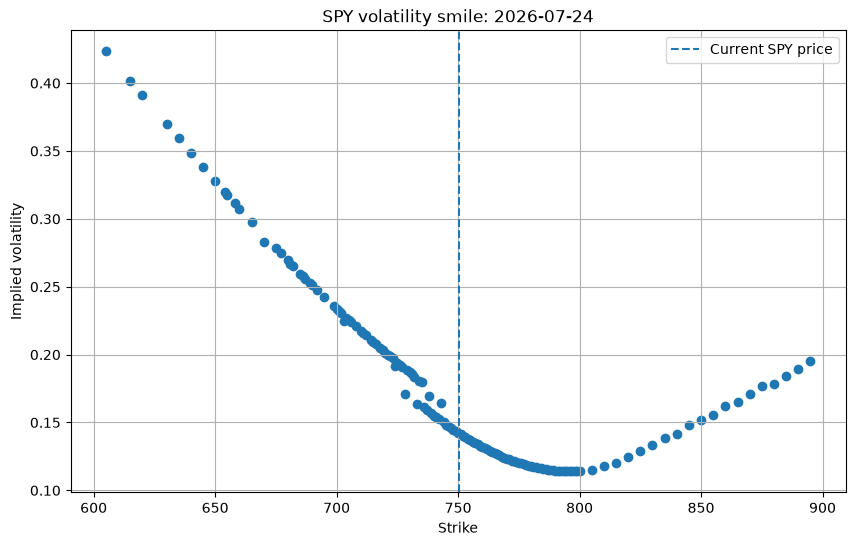

In [242]:
lower_strike = 0.8 * spot_price
upper_strike = 1.2 * spot_price

calls_near_money = calls[
    calls["strike"].between(
        lower_strike,
        upper_strike
    )
].copy()

plt.figure(figsize=(10, 6))

plt.scatter(
    calls_near_money["strike"],
    calls_near_money["impliedVolatility"]
)

plt.axvline(
    spot_price,
    linestyle="--",
    label="Current SPY price"
)

plt.xlabel("Strike")
plt.ylabel("Implied volatility")
plt.title(f"SPY volatility smile: {expiration}")
plt.legend()
plt.grid()

plt.show()

In [243]:
today = pd.Timestamp.now().normalize()
expiration_date = pd.Timestamp(expiration)

days_to_expiration = (expiration_date - today).days

T = days_to_expiration / 365

print("Days to expiration:", days_to_expiration)
print("Time to maturity:", T)

Days to expiration: 37
Time to maturity: 0.10136986301369863


In [244]:
forward_price = spot_price
calls_near_money["log_moneyness"] = np.log(calls_near_money["strike"] / forward_price)

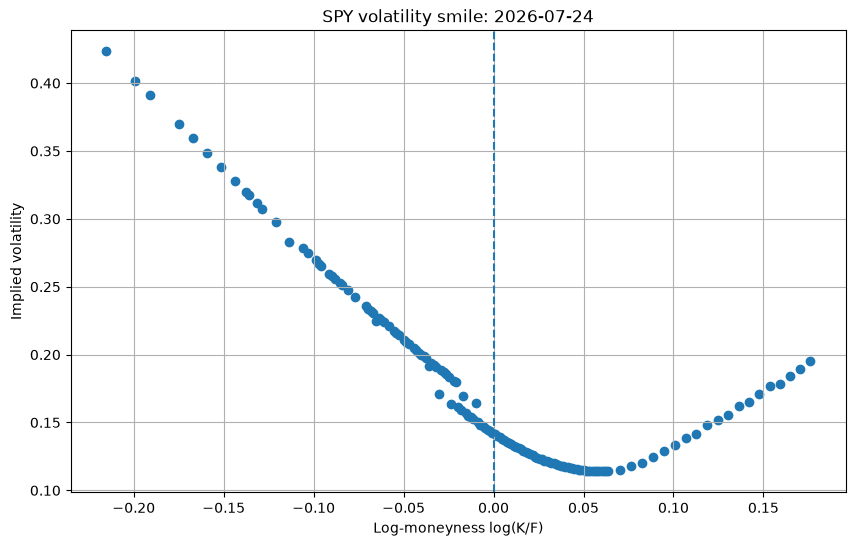

In [245]:
plt.figure(figsize=(10, 6))

plt.scatter(
    calls_near_money["log_moneyness"],
    calls_near_money["impliedVolatility"]
)
plt.axvline(0, linestyle="--")
plt.xlabel("Log-moneyness log(K/F)")
plt.ylabel("Implied volatility")
plt.title(f"SPY volatility smile: {expiration}")
plt.grid()
plt.show()

In [246]:
from scipy.stats import norm
from scipy.optimize import brentq
import math

In [247]:
today = pd.Timestamp.now().normalize()
expiration_date = pd.Timestamp(expiration)

days_to_expiration = (expiration_date - today).days
T = days_to_expiration / 365

print("Days to expiration:", days_to_expiration)
print("T:", T)

Days to expiration: 37
T: 0.10136986301369863


In [248]:
r = 0.04

forward_price = spot_price * np.exp(r * T)

print("Spot:", spot_price)
print("Forward:", forward_price)

Spot: 750.4849853515625
Forward: 753.5342256014449


In [249]:
def black_call_price(F, K, T, r, sigma):
    if sigma <= 0 or T <= 0:
        return np.nan

    d1 = (
        np.log(F / K)
        + 0.5 * sigma**2 * T
    ) / (sigma * np.sqrt(T))

    d2 = d1 - sigma * np.sqrt(T)

    call_price = np.exp(-r * T) * (
        F * norm.cdf(d1)
        - K * norm.cdf(d2)
    )

    return call_price

In [250]:
test_price = black_call_price(
    F=forward_price,
    K=spot_price,
    T=T,
    r=r,
    sigma=0.20
)

print("Call price with 20% volatility:", test_price)

Call price with 20% volatility: 20.580190392595156


In [251]:
def calculate_implied_volatility(
    market_price,
    F,
    K,
    T,
    r
):
    def difference(sigma):
        model_price = black_call_price(
            F=F,
            K=K,
            T=T,
            r=r,
            sigma=sigma
        )

        return model_price - market_price

    try:
        implied_vol = brentq(
            difference,
            0.0001,
            5.0
        )

        return implied_vol

    except ValueError:
        return np.nan

In [252]:
atm_index = (
    calls["strike"] - spot_price
).abs().idxmin()

test_option = calls.loc[atm_index]



In [253]:
my_iv = calculate_implied_volatility(
    market_price=test_option["mid_price"],
    F=forward_price,
    K=test_option["strike"],
    T=T,
    r=r
)

print("My implied volatility:", my_iv)
print(
    "Yahoo implied volatility:",
    test_option["impliedVolatility"]
)

My implied volatility: 0.12780957153771838
Yahoo implied volatility: 0.14252566467285155


In [254]:
calls["my_implied_volatility"] = calls.apply(
    lambda row: calculate_implied_volatility(
        market_price=row["mid_price"],
        F=forward_price,
        K=row["strike"],
        T=T,
        r=r
    ),
    axis=1
)

In [255]:
calls = calls.dropna(
    subset=["my_implied_volatility"]
)

In [256]:
calls[
    [
        "strike",
        "mid_price",
        "impliedVolatility",
        "my_implied_volatility"
    ]
].head(10)

,strike,mid_price,impliedVolatility,my_implied_volatility
28,687.0,66.315,0.255897,0.115348
29,689.0,64.430,0.253059,0.129521
30,690.0,63.320,0.251228,0.108588
31,692.0,62.230,0.247688,0.169360
32,695.0,59.425,0.242439,0.168955
33,699.0,55.735,0.235542,0.168525
34,700.0,54.840,0.233955,0.168926
35,701.0,53.890,0.232155,0.167699
36,702.0,52.995,0.230507,0.167877
37,703.0,51.430,0.224800,0.149167


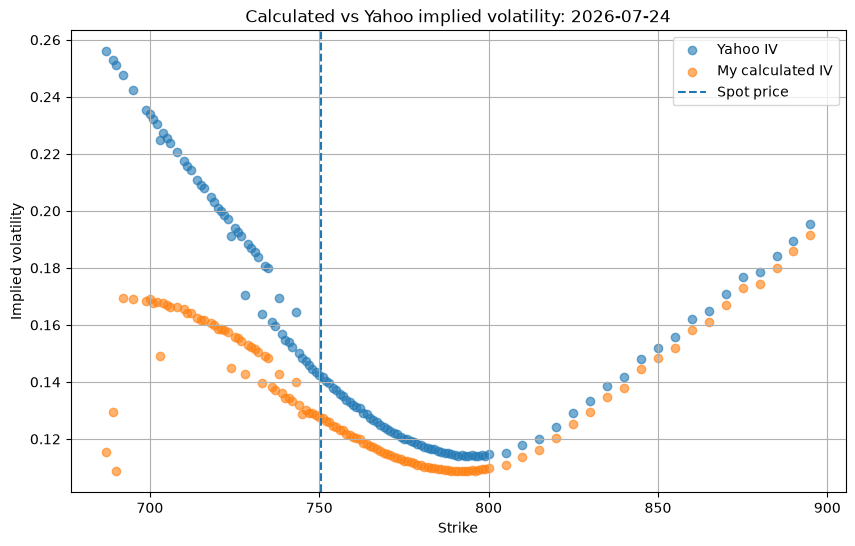

In [257]:
plt.figure(figsize=(10, 6))

plt.scatter(
    calls["strike"],
    calls["impliedVolatility"],
    label="Yahoo IV",
    alpha=0.6
)

plt.scatter(
    calls["strike"],
    calls["my_implied_volatility"],
    label="My calculated IV",
    alpha=0.6
)

plt.axvline(
    spot_price,
    linestyle="--",
    label="Spot price"
)

plt.xlabel("Strike")
plt.ylabel("Implied volatility")
plt.title(
    f"Calculated vs Yahoo implied volatility: {expiration}"
)

plt.legend()
plt.grid()
plt.show()

In [258]:
option_chain = ticker.option_chain(expiration)

calls = option_chain.calls.copy()
puts = option_chain.puts.copy()

In [259]:
def clean_options(options):
    options = options.copy()

    options = options[
        (options["bid"] > 0) &
        (options["ask"] > options["bid"])
    ].copy()

    options["mid_price"] = (
        options["bid"] + options["ask"]
    ) / 2

    options["relative_spread"] = (
        options["ask"] - options["bid"]
    ) / options["mid_price"]

    options = options[
        options["relative_spread"] < 0.30
    ].copy()

    options = options[
        options["openInterest"] > 0
    ].copy()

    return options

In [260]:
calls = clean_options(calls)
puts = clean_options(puts)

In [261]:
call_put_pairs = calls[
    ["strike", "mid_price", "relative_spread"]
].merge(
    puts[
        ["strike", "mid_price", "relative_spread"]
    ],
    on="strike",
    suffixes=("_call", "_put")
)

In [262]:
call_put_pairs.head()

,strike,mid_price_call,relative_spread_call,mid_price_put,relative_spread_put
0,500.0,250.145,0.013472,0.165,0.060606
1,540.0,210.425,0.015635,0.265,0.037736
2,550.0,200.530,0.016656,0.295,0.033898
3,560.0,190.615,0.017575,0.335,0.029851
4,570.0,180.675,0.018209,0.375,0.026667


In [263]:
call_put_pairs["forward_candidate"] = (
    call_put_pairs["strike"]
    + np.exp(r * T) * (
        call_put_pairs["mid_price_call"]
        - call_put_pairs["mid_price_put"]
    )
)

In [264]:
call_put_pairs[
    [
        "strike",
        "mid_price_call",
        "mid_price_put",
        "forward_candidate"
    ]
].head(20)

,strike,mid_price_call,mid_price_put,forward_candidate
0,500.0,250.145,0.165,750.995675
1,540.0,210.425,0.265,751.013886
2,550.0,200.530,0.295,751.048560
3,560.0,190.615,0.335,751.053113
4,570.0,180.675,0.375,751.032564
5,595.0,155.950,0.505,751.076577
6,600.0,151.000,0.530,751.081364
7,605.0,146.065,0.565,751.091170
8,615.0,136.235,0.640,751.145926
9,620.0,131.285,0.680,751.135652


In [265]:
near_atm_pairs = call_put_pairs[
    call_put_pairs["strike"].between(
        0.90 * spot_price,
        1.10 * spot_price
    )
].copy()

In [266]:
near_atm_pairs["pair_spread"] = (
    near_atm_pairs["relative_spread_call"]
    + near_atm_pairs["relative_spread_put"]
)

best_pairs = near_atm_pairs.nsmallest(
    max(3, len(near_atm_pairs) // 2),
    "pair_spread"
)

best_pairs

,strike,mid_price_call,relative_spread_call,mid_price_put,relative_spread_put,forward_candidate,pair_spread
80,750.0,13.995,0.002144,13.045,0.003833,750.953860,0.005977
79,749.0,14.585,0.002057,12.605,0.003967,750.988045,0.006024
81,751.0,13.430,0.002978,13.435,0.003722,750.994980,0.006700
78,748.0,15.210,0.002630,12.195,0.004100,751.027250,0.006730
82,752.0,12.810,0.003123,13.845,0.003611,750.960795,0.006734
83,753.0,12.270,0.003260,14.295,0.003498,750.966772,0.006758
84,754.0,11.660,0.003431,14.735,0.003393,750.912506,0.006824
85,755.0,11.130,0.003594,15.210,0.003945,750.903423,0.007539
77,747.0,15.790,0.010133,11.850,0.003376,750.956008,0.013509
58,728.0,29.765,0.009071,6.695,0.004481,751.163734,0.013552


In [267]:
forward_price = best_pairs[
    "forward_candidate"
].median()

print("Spot price:", spot_price)
print("Market-implied forward:", forward_price)

Spot price: 750.4849853515625
Market-implied forward: 751.0652531944752


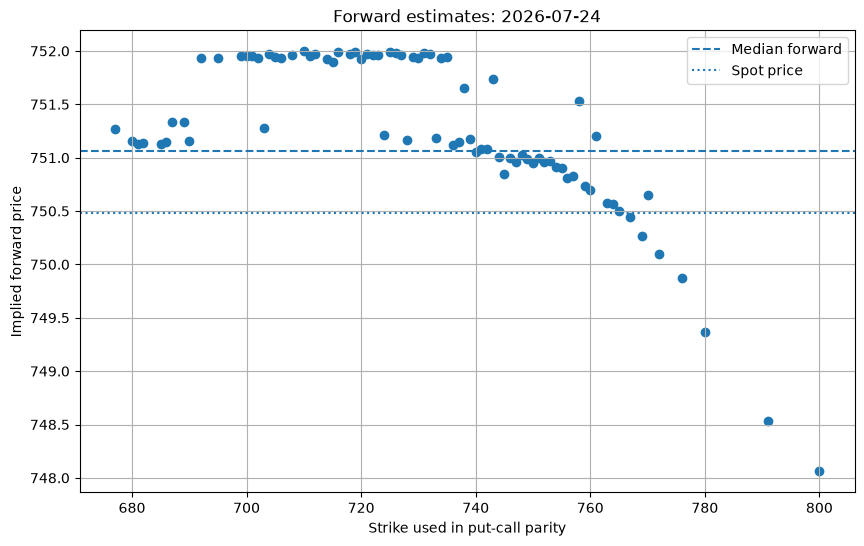

In [268]:
plt.figure(figsize=(10, 6))

plt.scatter(
    near_atm_pairs["strike"],
    near_atm_pairs["forward_candidate"]
)

plt.axhline(
    forward_price,
    linestyle="--",
    label="Median forward"
)

plt.axhline(
    spot_price,
    linestyle=":",
    label="Spot price"
)

plt.xlabel("Strike used in put-call parity")
plt.ylabel("Implied forward price")
plt.title(f"Forward estimates: {expiration}")
plt.legend()
plt.grid()
plt.show()

In [269]:
def black_put_price(F, K, T, r, sigma):
    if sigma <= 0 or T <= 0:
        return np.nan

    d1 = (
        np.log(F / K)
        + 0.5 * sigma**2 * T
    ) / (sigma * np.sqrt(T))

    d2 = d1 - sigma * np.sqrt(T)

    put_price = np.exp(-r * T) * (
        K * norm.cdf(-d2)
        - F * norm.cdf(-d1)
    )

    return put_price

In [270]:
def calculate_implied_volatility_upd(
    market_price,
    F,
    K,
    T,
    r,
    option_type
):
    def difference(sigma):

        if option_type == "call":
            model_price = black_call_price(
                F=F,
                K=K,
                T=T,
                r=r,
                sigma=sigma
            )

        elif option_type == "put":
            model_price = black_put_price(
                F=F,
                K=K,
                T=T,
                r=r,
                sigma=sigma
            )

        else:
            raise ValueError(
                "option_type must be call or put"
            )

        return model_price - market_price

    try:
        return brentq(
            difference,
            0.0001,
            5.0
        )

    except ValueError:
        return np.nan

In [271]:
otm_puts = puts[
    puts["strike"] < forward_price
].copy()

In [272]:
otm_calls = calls[
    calls["strike"] >= forward_price
].copy()

In [273]:
otm_puts["my_implied_volatility"] = otm_puts.apply(
    lambda row: calculate_implied_volatility_upd(
        market_price=row["mid_price"],
        F=forward_price,
        K=row["strike"],
        T=T,
        r=r,
        option_type="put"
    ),
    axis=1
)

In [274]:
otm_puts["option_type"] = "put"

In [275]:
otm_calls["my_implied_volatility"] = otm_calls.apply(
    lambda row: calculate_implied_volatility_upd(
        market_price=row["mid_price"],
        F=forward_price,
        K=row["strike"],
        T=T,
        r=r,
        option_type="call"
    ),
    axis=1
)

In [276]:
otm_calls["option_type"] = "call"

In [277]:
smile_data = pd.concat(
    [
        otm_puts,
        otm_calls
    ],
    ignore_index=True
)

In [278]:
smile_data = smile_data.dropna(
    subset=["my_implied_volatility"]
)

In [279]:
smile_data = smile_data[
    smile_data["my_implied_volatility"].between(
        0.01,
        2.0
    )
].copy()

In [280]:
smile_data = smile_data.sort_values("strike")

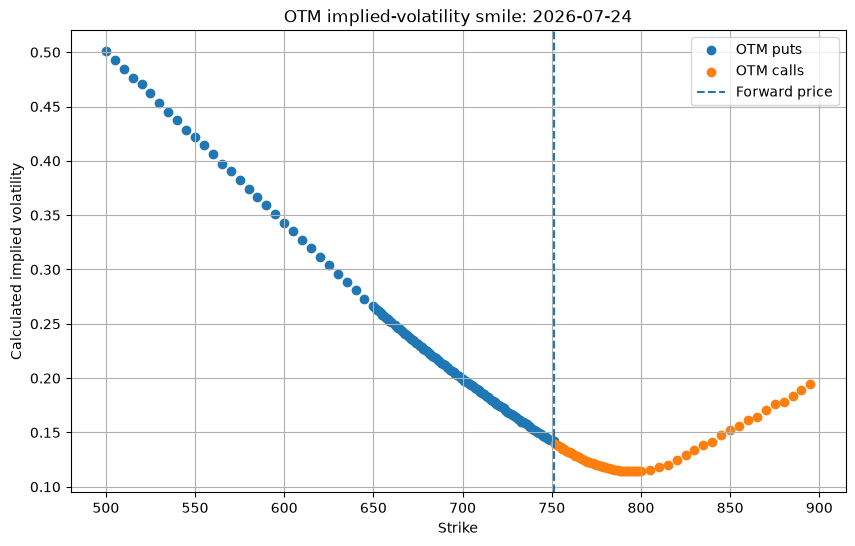

In [281]:
plt.figure(figsize=(10, 6))

put_data = smile_data[
    smile_data["option_type"] == "put"
]

call_data = smile_data[
    smile_data["option_type"] == "call"
]

plt.scatter(
    put_data["strike"],
    put_data["my_implied_volatility"],
    label="OTM puts"
)

plt.scatter(
    call_data["strike"],
    call_data["my_implied_volatility"],
    label="OTM calls"
)

plt.axvline(
    forward_price,
    linestyle="--",
    label="Forward price"
)

plt.xlabel("Strike")
plt.ylabel("Calculated implied volatility")
plt.title(
    f"OTM implied-volatility smile: {expiration}"
)
plt.legend()
plt.grid()
plt.show()

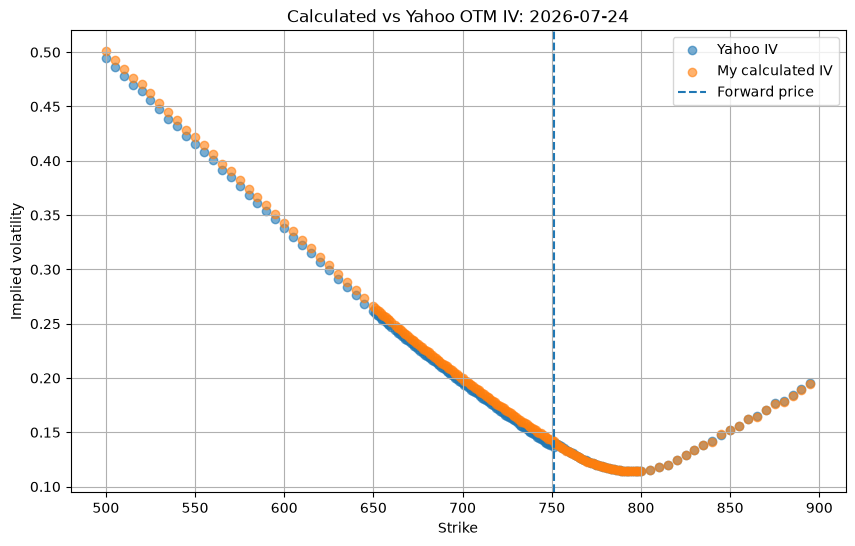

In [282]:
plt.figure(figsize=(10, 6))

plt.scatter(
    smile_data["strike"],
    smile_data["impliedVolatility"],
    label="Yahoo IV",
    alpha=0.6
)

plt.scatter(
    smile_data["strike"],
    smile_data["my_implied_volatility"],
    label="My calculated IV",
    alpha=0.6
)

plt.axvline(
    forward_price,
    linestyle="--",
    label="Forward price"
)

plt.xlabel("Strike")
plt.ylabel("Implied volatility")
plt.title(
    f"Calculated vs Yahoo OTM IV: {expiration}"
)
plt.legend()
plt.grid()
plt.show()

In [283]:
def estimate_forward(calls, puts, spot_price, T, r):
    call_put_pairs = calls[
        ["strike", "mid_price", "relative_spread"]
    ].merge(
        puts[
            ["strike", "mid_price", "relative_spread"]
        ],
        on="strike",
        suffixes=("_call", "_put")
    )

    call_put_pairs["forward_candidate"] = (
        call_put_pairs["strike"]
        + np.exp(r * T) * (
            call_put_pairs["mid_price_call"]
            - call_put_pairs["mid_price_put"]
        )
    )

    near_atm_pairs = call_put_pairs[
        call_put_pairs["strike"].between(
            0.90 * spot_price,
            1.10 * spot_price
        )
    ].copy()

    near_atm_pairs["pair_spread"] = (
        near_atm_pairs["relative_spread_call"]
        + near_atm_pairs["relative_spread_put"]
    )

    if len(near_atm_pairs) < 3:
        return np.nan

    best_pairs = near_atm_pairs.nsmallest(
        max(3, len(near_atm_pairs) // 2),
        "pair_spread"
    )

    forward_price = best_pairs[
        "forward_candidate"
    ].median()

    return forward_price

In [284]:
selected_expirations = expirations[:30]

print("Selected expirations:", len(selected_expirations))

Selected expirations: 30


In [285]:
def build_smile_for_expiration(expiration, spot_price, r):
    expiration_date = pd.Timestamp(expiration)
    today = pd.Timestamp.now().normalize()
    T = (expiration_date - today).days / 365

    if T <= 0:
        return pd.DataFrame()

    option_chain = ticker.option_chain(expiration)
    calls = clean_options(option_chain.calls)
    puts = clean_options(option_chain.puts)

    forward_price = estimate_forward(
        calls=calls,
        puts=puts,
        spot_price=spot_price,
        T=T,
        r=r
    )

    if np.isnan(forward_price):
        return pd.DataFrame()

    otm_puts = puts[
        puts["strike"] < forward_price
    ].copy()

    otm_calls = calls[
        calls["strike"] >= forward_price
    ].copy()

    otm_puts["my_implied_volatility"] = otm_puts.apply(
        lambda row: calculate_implied_volatility_upd(
            market_price=row["mid_price"],
            F=forward_price,
            K=row["strike"],
            T=T,
            r=r,
            option_type="put"
        ),
        axis=1
    )

    otm_calls["my_implied_volatility"] = otm_calls.apply(
        lambda row: calculate_implied_volatility_upd(
            market_price=row["mid_price"],
            F=forward_price,
            K=row["strike"],
            T=T,
            r=r,
            option_type="call"
        ),
        axis=1
    )

    otm_puts["option_type"] = "put"
    otm_calls["option_type"] = "call"

    smile = pd.concat(
        [otm_puts, otm_calls],
        ignore_index=True
    )

    smile = smile.dropna(
        subset=["my_implied_volatility"]
    )

    smile = smile[
        smile["my_implied_volatility"].between(0.01, 2.0)
    ].copy()

    smile["expiration"] = expiration
    smile["T"] = T
    smile["forward"] = forward_price
    smile["log_moneyness"] = np.log(
        smile["strike"] / forward_price
    )
    smile["total_variance"] = (
        smile["my_implied_volatility"] ** 2 * T
    )

    smile = smile[
        smile["log_moneyness"].between(-0.35, 0.35)
    ].copy()

    return smile.sort_values("strike")

In [286]:
all_smiles = []

for expiration in selected_expirations:
    print("Processing:", expiration)

    try:
        smile = build_smile_for_expiration(
            expiration=expiration,
            spot_price=spot_price,
            r=r
        )
    except Exception as error:
        print(f"Skipped {expiration}: {error}")
        continue

    if smile.empty:
        print(f"Skipped {expiration}: no usable quotes")
        continue

    all_smiles.append(smile)
    print(
        f"Added {len(smile)} quotes, "
        f"forward={smile['forward'].iloc[0]:.2f}"
    )

if not all_smiles:
    raise RuntimeError("No usable smiles were built from the selected expirations")

surface_data = pd.concat(
    all_smiles,
    ignore_index=True
)

surface_data = surface_data.sort_values(
    ["T", "strike", "option_type"]
).reset_index(drop=True)

Processing: 2026-06-17
Skipped 2026-06-17: no usable quotes
Processing: 2026-06-18
Added 85 quotes, forward=748.95
Processing: 2026-06-22
Added 89 quotes, forward=748.13
Processing: 2026-06-23
Added 94 quotes, forward=748.04
Processing: 2026-06-24
Added 100 quotes, forward=748.14
Processing: 2026-06-25
Added 98 quotes, forward=748.25
Processing: 2026-06-26
Added 124 quotes, forward=748.50
Processing: 2026-06-29
Added 83 quotes, forward=748.60
Processing: 2026-06-30
Added 276 quotes, forward=748.71
Processing: 2026-07-02
Added 181 quotes, forward=749.30
Processing: 2026-07-10
Added 195 quotes, forward=749.92
Processing: 2026-07-17
Added 192 quotes, forward=750.53
Processing: 2026-07-24
Added 193 quotes, forward=751.11
Processing: 2026-07-31
Added 217 quotes, forward=751.81
Processing: 2026-08-21
Added 202 quotes, forward=753.44
Processing: 2026-08-31
Added 214 quotes, forward=754.18
Processing: 2026-09-18
Added 252 quotes, forward=755.18
Processing: 2026-09-30
Added 152 quotes, forward=

In [287]:
summary = (
    surface_data.groupby("expiration")
    .agg(
        T=("T", "first"),
        forward=("forward", "first"),
        quotes=("strike", "size"),
        min_strike=("strike", "min"),
        max_strike=("strike", "max"),
    )
    .reset_index()
)

print("Number of expirations:", surface_data["expiration"].nunique())
print("Total quotes:", len(surface_data))
summary.head(30)

Number of expirations: 29
Total quotes: 4203


,expiration,T,forward,quotes,min_strike,max_strike
0,2026-06-18,0.002740,748.946364,85,685.0,770.0
1,2026-06-22,0.013699,748.126713,89,640.0,776.0
2,2026-06-23,0.016438,748.042000,94,625.0,778.0
3,2026-06-24,0.019178,748.135104,100,600.0,780.0
4,2026-06-25,0.021918,748.245344,98,580.0,785.0
5,2026-06-26,0.024658,748.504441,124,555.0,794.0
6,2026-06-29,0.032877,748.596297,83,540.0,805.0
7,2026-06-30,0.035616,748.708144,276,528.0,815.0
8,2026-07-02,0.041096,749.301303,181,530.0,835.0
9,2026-07-10,0.063014,749.922426,195,530.0,870.0


In [288]:
surface_data[
    [
        "expiration",
        "option_type",
        "strike",
        "T",
        "forward",
        "log_moneyness",
        "my_implied_volatility",
        "total_variance",
    ]
].head(20)

,expiration,option_type,strike,T,forward,log_moneyness,my_implied_volatility,total_variance
0,2026-06-18,put,685.0,0.00274,748.946364,-0.089249,0.653853,0.001171
1,2026-06-18,put,686.0,0.00274,748.946364,-0.087790,0.644254,0.001137
2,2026-06-18,put,687.0,0.00274,748.946364,-0.086333,0.634657,0.001104
3,2026-06-18,put,688.0,0.00274,748.946364,-0.084879,0.625061,0.001070
4,2026-06-18,put,689.0,0.00274,748.946364,-0.083426,0.615466,0.001038
5,2026-06-18,put,690.0,0.00274,748.946364,-0.081976,0.605871,0.001006
6,2026-06-18,put,691.0,0.00274,748.946364,-0.080528,0.596276,0.000974
7,2026-06-18,put,692.0,0.00274,748.946364,-0.079081,0.586681,0.000943
8,2026-06-18,put,693.0,0.00274,748.946364,-0.077637,0.593562,0.000965
9,2026-06-18,put,694.0,0.00274,748.946364,-0.076195,0.583742,0.000934


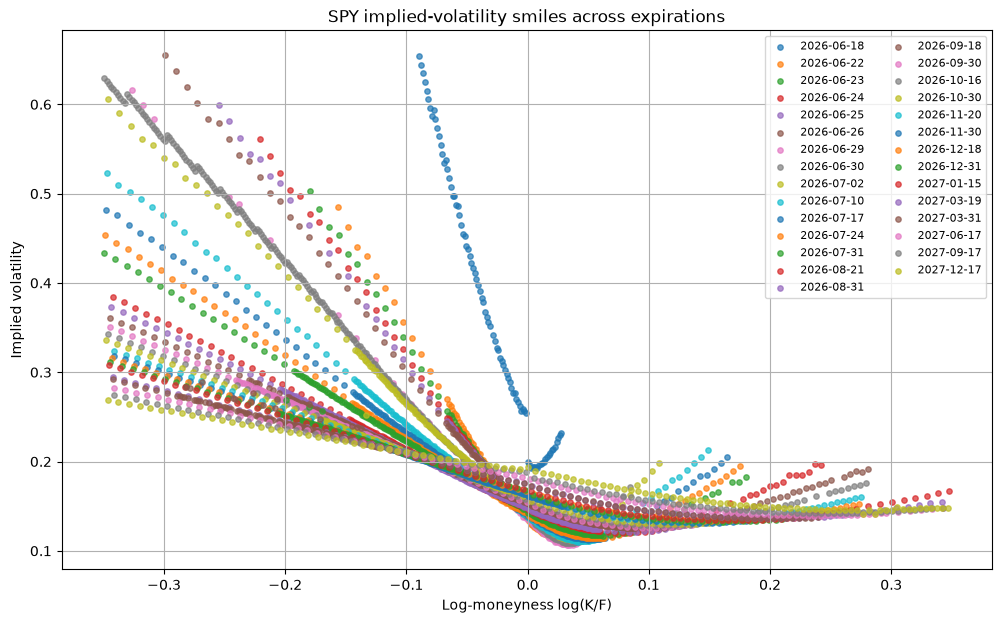

In [290]:
plt.figure(figsize=(12, 7))

for expiration, data in surface_data.groupby("expiration"):
    plt.scatter(
        data["log_moneyness"],
        data["my_implied_volatility"],
        label=expiration,
        s=15,
        alpha=0.7
    )

plt.xlabel("Log-moneyness log(K/F)")
plt.ylabel("Implied volatility")
plt.title("SPY implied-volatility smiles across expirations")
plt.legend(fontsize=8, ncol=2)
plt.grid()
plt.show()

## 3D implied-volatility surface

Run this after `surface_data` has been built. It plots log-moneyness, days to expiration, and implied volatility.


In [ ]:
import plotly.graph_objects as go
from scipy.interpolate import griddata

plot_data["total_variance"] = (
    plot_data["my_implied_volatility"] ** 2
    * plot_data["T"]
)


k_grid = np.linspace(
    plot_data["log_moneyness"].quantile(0.02),
    plot_data["log_moneyness"].quantile(0.98),
    80
)

t_grid = np.linspace(
    plot_data["T"].min(),
    plot_data["T"].max(),
    60
)

K_GRID, T_GRID = np.meshgrid(
    k_grid,
    t_grid
)

W_GRID = griddata(
    points=plot_data[
        ["log_moneyness", "T"]
    ].to_numpy(),
    values=plot_data[
        "total_variance"
    ].to_numpy(),
    xi=(K_GRID, T_GRID),
    method="linear"
)

IV_GRID = np.sqrt(
    W_GRID / T_GRID
)

fig = go.Figure()

fig.add_trace(
    go.Surface(
        x=K_GRID,
        y=T_GRID * 365,
        z=IV_GRID,
        colorscale="Viridis",
        opacity=0.85,
        name="Interpolated IV surface",
        showscale=True,
        colorbar={"title": "IV"}
    )
)

fig.add_trace(
    go.Scatter3d(
        x=plot_data["log_moneyness"],
        y=plot_data["T"] * 365,
        z=plot_data["my_implied_volatility"],
        mode="markers",
        marker={
            "size": 2,
            "color": plot_data["my_implied_volatility"],
            "colorscale": "Viridis",
            "opacity": 0.45,
        },
        text=plot_data["expiration"],
        name="Option quotes"
    )
)

fig.update_layout(
    title="SPY implied-volatility surface",
    scene={
        "xaxis_title": "Log-moneyness log(K/F)",
        "yaxis_title": "Days to expiration",
        "zaxis_title": "Implied volatility",
    },
    height=750,
    margin={"l": 0, "r": 0, "b": 0, "t": 50},
)

fig.show()


In [293]:
def get_surface_iv(log_moneyness, T):
    iv = griddata(
        points=np.column_stack([
            K_GRID.ravel(),
            T_GRID.ravel()
        ]),
        values=IV_GRID.ravel(),
        xi=np.array([[log_moneyness, T]]),
        method="linear"
    )[0]

    return iv

In [294]:
test_k = 0.0
test_T = 90 / 365

test_iv = get_surface_iv(test_k, test_T)

print("Surface IV:", test_iv)

Surface IV: 0.15208041394428137


In [295]:
target_days = 90
target_T = target_days / 365
target_K = 0.95 * spot_price

In [296]:
forward_curve = (
    surface_data
    .groupby("T")["forward"]
    .median()
    .reset_index()
    .sort_values("T")
)

target_forward = np.interp(
    target_T,
    forward_curve["T"],
    forward_curve["forward"]
)

print("Target forward:", target_forward)

Target forward: 755.011252998822


In [297]:
target_k = np.log(
    target_K / target_forward
)

print("Target log-moneyness:", target_k)

Target log-moneyness: -0.057306303480101004


In [298]:
target_iv = get_surface_iv(
    target_k,
    target_T
)

print("Target IV:", target_iv)

Target IV: 0.1850658923221167


In [299]:
def digital_call_price(F, K, T, r, sigma):
    d2 = (
        np.log(F / K)
        - 0.5 * sigma**2 * T
    ) / (sigma * np.sqrt(T))

    price = np.exp(-r * T) * norm.cdf(d2)

    return price

In [300]:
digital_price = digital_call_price(
    F=target_forward,
    K=target_K,
    T=target_T,
    r=r,
    sigma=target_iv
)

print("Digital call price:", digital_price)

Digital call price: 0.7111986365206446


In [301]:
notional = 10_000

print(
    "Contract value:",
    digital_price * notional
)

Contract value: 7111.986365206446


In [302]:
atm_iv = get_surface_iv(
    log_moneyness=0.0,
    T=target_T
)

In [303]:
flat_price = digital_call_price(
    F=target_forward,
    K=target_K,
    T=target_T,
    r=r,
    sigma=atm_iv
)

print("Surface price:", digital_price)
print("Flat-vol price:", flat_price)
print("Difference:", digital_price - flat_price)

Surface price: 0.7111986365206446
Flat-vol price: 0.7570684900322568
Difference: -0.04586985351161221
